In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [6]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [7]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()



Вывести несколько первых строк сгруппированных данных

In [8]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

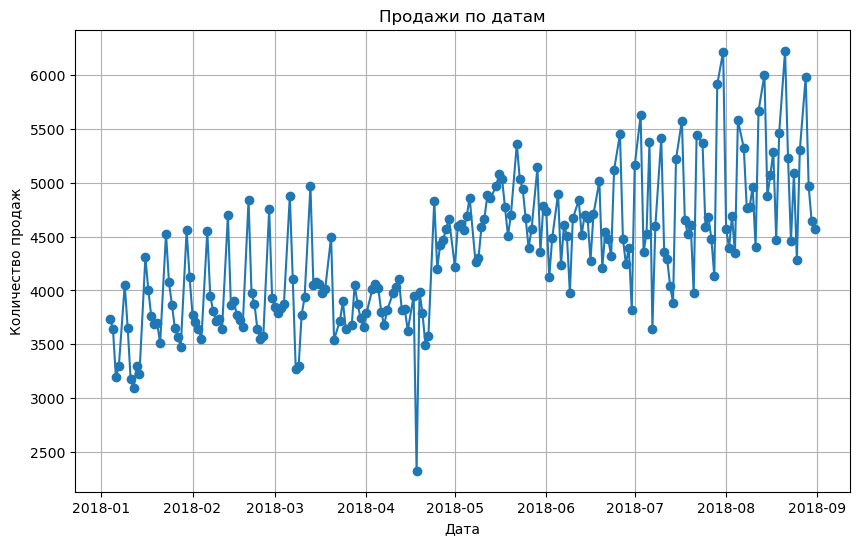

In [9]:

plt.figure(figsize=(10, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], marker='o', linestyle='-')
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Описание графика
Для финального текстового блока можете использовать следующее описание:
На графике наблюдается стабильный восходящий тренд: общие объемы продаж выросли с января по август 2018 года. 
Отчетливо видна еженедельная сезонность (характерные «зубцы»), что говорит о регулярных колебаниях спроса внутри недели. 
Самым заметным событием является резкий провал во второй половине апреля, когда продажи упали до минимального значения (около 2500 единиц). 
Начиная с июля, амплитуда колебаний увеличилась — разница между пиковыми и минимальными продажами стала более существенной.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [10]:
max_sale = df[df['Количество'] == df['Количество'].max()]
print(max_sale)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [11]:
top_wednesday_item = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

result = top_wednesday_item.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

print("Самый популярный товар:")
print(result.head(1))

Самый популярный товар:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

=== ПРОДАЖИ ===
Диапазон дат: 2018-01-04 00:00:00 — 2018-08-31 00:00:00
Строк: 205
        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055

=== ПЕРВЫЕ 5 СТРОК ПОГОДЫ (теперь должно быть правильно) ===
  Местное время в Астане     T
0       31.08.2018 23:00   8.2
1       31.08.2018 20:00   9.6
2       31.08.2018 17:00  11.3
3       31.08.2018 14:00  12.3
4       31.08.2018 11:00  13.2

=== ПОГОДА (средняя температура) ===
Диапазон дат: 2018-01-01 00:00:00 — 2018-08-31 00:00:00
Строк: 243
        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625

✅ Объединено 205 дней
        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500


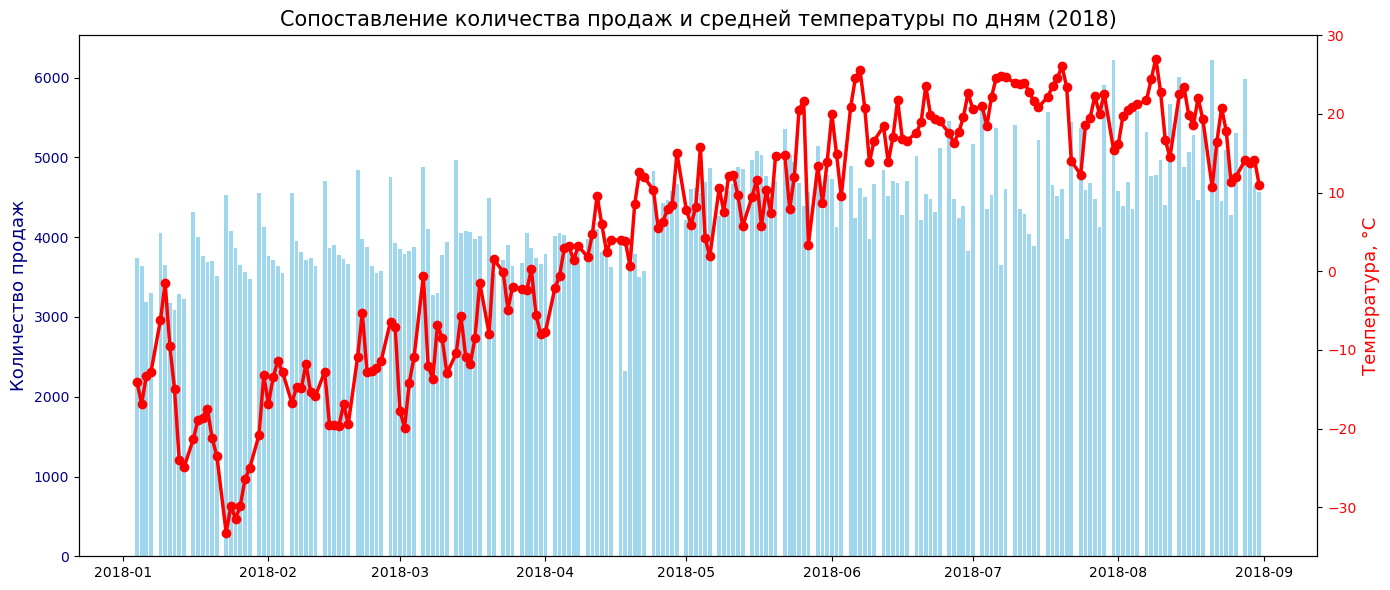

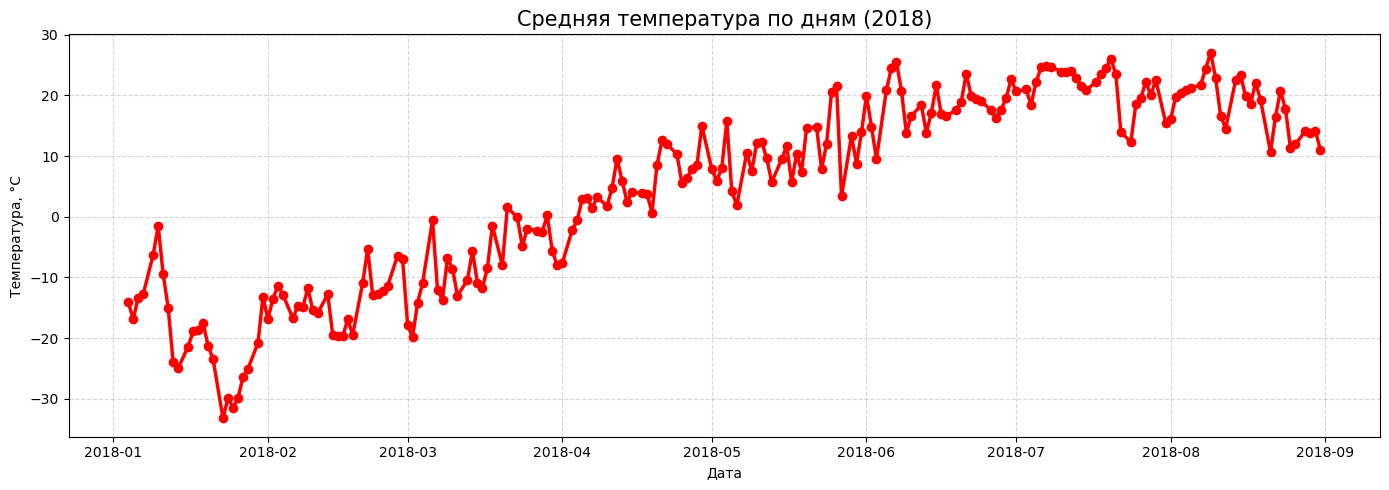

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ====================== 1. ПРОДАЖИ ======================
df['Дата'] = pd.to_datetime(df['Дата'], dayfirst=True, errors='coerce')
df['Дата'] = df['Дата'].dt.normalize()

grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

print("=== ПРОДАЖИ ===")
print("Диапазон дат:", grouped_df['Дата'].min(), "—", grouped_df['Дата'].max())
print("Строк:", len(grouped_df))
print(grouped_df.head(5))

# ====================== 2. ПОГОДА (ИСПРАВЛЕННОЕ ЧТЕНИЕ) ======================
weather = pd.read_csv(
    'архивв',
    sep=';',
    skiprows=6,
    encoding='utf-8',
    quotechar='"',
    header=0,
    engine='python',          # ← главное исправление
    index_col=False,          # ← убирает сдвиг колонок
    on_bad_lines='warn'       # ← не падает на проблемных строках
)

weather.columns = [c.strip().replace('"', '') for c in weather.columns]

# Диагностика
print("\n=== ПЕРВЫЕ 5 СТРОК ПОГОДЫ (теперь должно быть правильно) ===")
print(weather[['Местное время в Астане', 'T']].head())

weather['DT'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True, errors='coerce')
weather['Дата'] = weather['DT'].dt.normalize()
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

daily_temp = weather.groupby('Дата')['T'].mean().reset_index()

print("\n=== ПОГОДА (средняя температура) ===")
print("Диапазон дат:", daily_temp['Дата'].min(), "—", daily_temp['Дата'].max())
print("Строк:", len(daily_temp))
print(daily_temp.head(5))

# ====================== 3. ОБЪЕДИНЕНИЕ ======================
merged = pd.merge(grouped_df, daily_temp, on='Дата', how='inner').sort_values('Дата')

print(f"\n✅ Объединено {len(merged)} дней")

if len(merged) == 0:
    print("❌ Даты не совпадают. Пришлите вывод диагностики выше.")
else:
    print(merged.head())

# ====================== 4. ГРАФИКИ ======================
if len(merged) > 0:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.bar(merged['Дата'], merged['Количество'], color='skyblue', alpha=0.8)
    ax1.set_ylabel('Количество продаж', color='navy', fontsize=13)
    ax1.tick_params(axis='y', labelcolor='navy')

    ax2 = ax1.twinx()
    ax2.plot(merged['Дата'], merged['T'], color='red', marker='o', linewidth=2.5)
    ax2.set_ylabel('Температура, °C', color='red', fontsize=13)
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('Сопоставление количества продаж и средней температуры по дням (2018)', fontsize=15)
    plt.xlabel('Дата')
    fig.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

    # График только температуры
    plt.figure(figsize=(14, 5))
    plt.plot(merged['Дата'], merged['T'], color='red', marker='o', linewidth=2.5)
    plt.title('Средняя температура по дням (2018)', fontsize=15)
    plt.ylabel('Температура, °C')
    plt.xlabel('Дата')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Графики не построены — нет совпадающих дат.")

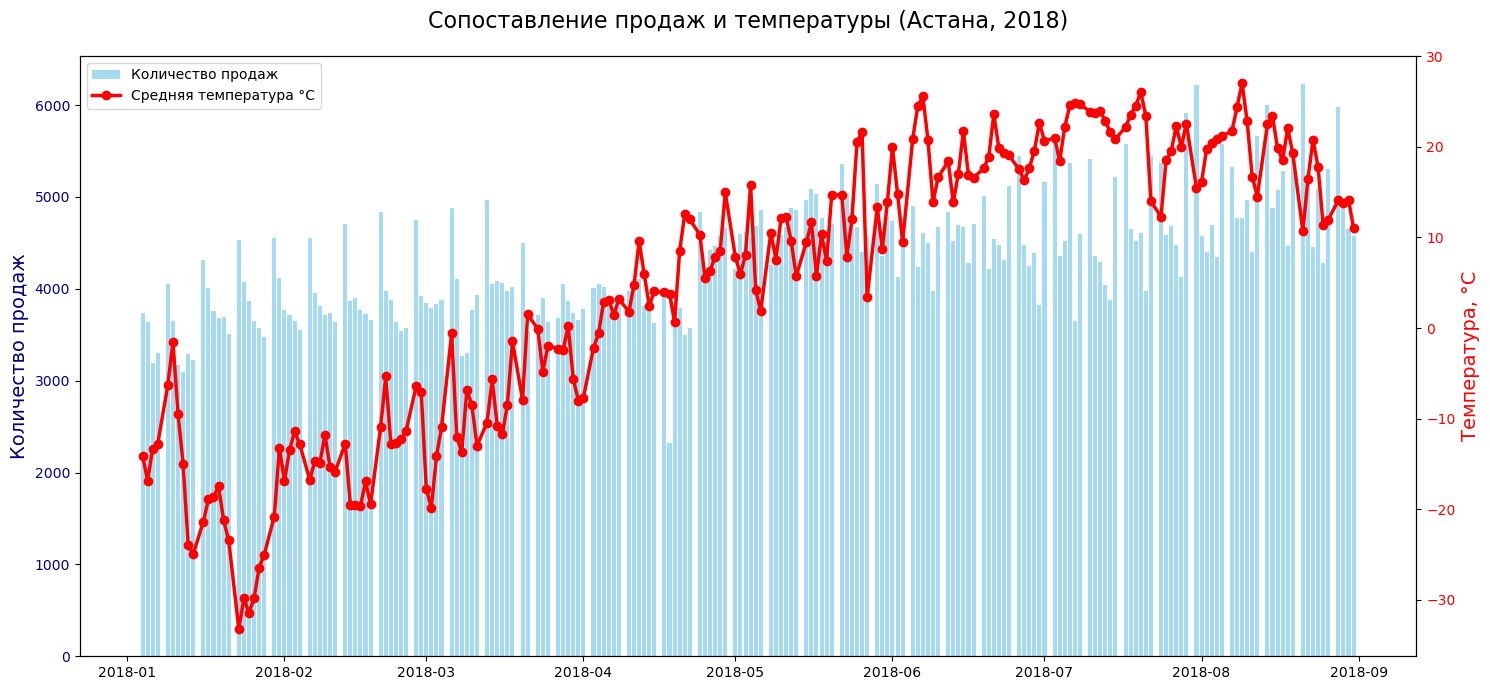

In [26]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(merged['Дата'], merged['Количество'], color='skyblue', alpha=0.75, label='Количество продаж')
ax1.set_ylabel('Количество продаж', color='navy', fontsize=14)
ax1.tick_params(axis='y', labelcolor='navy')

ax2 = ax1.twinx()
ax2.plot(merged['Дата'], merged['T'], color='red', marker='o', linewidth=2.5, label='Средняя температура °C')
ax2.set_ylabel('Температура, °C', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Сопоставление продаж и температуры (Астана, 2018)', fontsize=16, pad=20)
plt.xlabel('Дата')
fig.tight_layout()

# Легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()